**PROJECT-BASED INTERNSHIP VINIX7**

**Modul 4: Exploratory Data Analysis (EDA)**

Kelompok 3 (Universitas Sultan Ageng Tirtayasa)

Anggota Kelompok: Ahmad Jumhadi, Azhriler Lintang, Aura Salsa Azzahra

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Kode ini menunjukkan tahap awal dalam proses analisis data, yaitu melakukan import library yang dibutuhkan. Terdapat tiga library utama yang digunakan, yaitu pandas, matplotlib, dan seaborn. Library pandas digunakan untuk manipulasi dan analisis data tabular, Library matplotlib digunakan untuk membuat visualisasi data seperti grafik dan plot, sedangkan Library seaborn digunakan untuk menghasilkan visualisasi data yang lebih menarik dan informatif.

In [ ]:
def load_and_prep_data():
    pass

df = pd.read_csv('tokopedia_product_reviews_2025.csv')
df['review_date'] = pd.to_datetime(df['review_date'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   review_text       65543 non-null  object        
 1   review_date       65543 non-null  datetime64[ns]
 2   review_id         65543 non-null  int64         
 3   product_name      65543 non-null  object        
 4   product_category  65543 non-null  object        
 5   product_variant   26749 non-null  object        
 6   product_price     65543 non-null  int64         
 7   product_url       65543 non-null  object        
 8   product_id        65543 non-null  int64         
 9   rating            65543 non-null  int64         
 10  sold_count        65543 non-null  int64         
 11  shop_id           65543 non-null  int64         
 12  sentiment_label   65543 non-null  object        
dtypes: datetime64[ns](1), int64(6), object(6)
memory usage: 6.5+ MB
None


Output ini menunjukkan tahap load data dan data preparation dalam proses analisis. Sistem telah berhasil membaca file dataset dan kolom 'review_date' telah dikonversi ke tipe datetime. Selain itu, tipe data numerik dan teks sudah sesuai pada setiap kolom untuk digunakan pada tahap analisis berikutnya.

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
review_text             0
review_date             0
review_id               0
product_name            0
product_category        0
product_variant     38794
product_price           0
product_url             0
product_id              0
rating                  0
sold_count              0
shop_id                 0
sentiment_label         0
dtype: int64


**Interpretasi 1:** Berdasarkan hasil pengecekan missing values, hanya kolom 'product_variant' yang memiliki nilai kosong dalam jumlah yang banyak, sebesar 38.794 baris, sementara kolom lainnya tidak memiliki missing values. Missing value pada kolom 'product_variant' tidak dihapus dan dibiarkan saja, karena kolom ini bersifat opsional dan tidak semua produk memiliki varian, sehingga nilai kosong masih bersifat relevan dalam konteks bisnis.

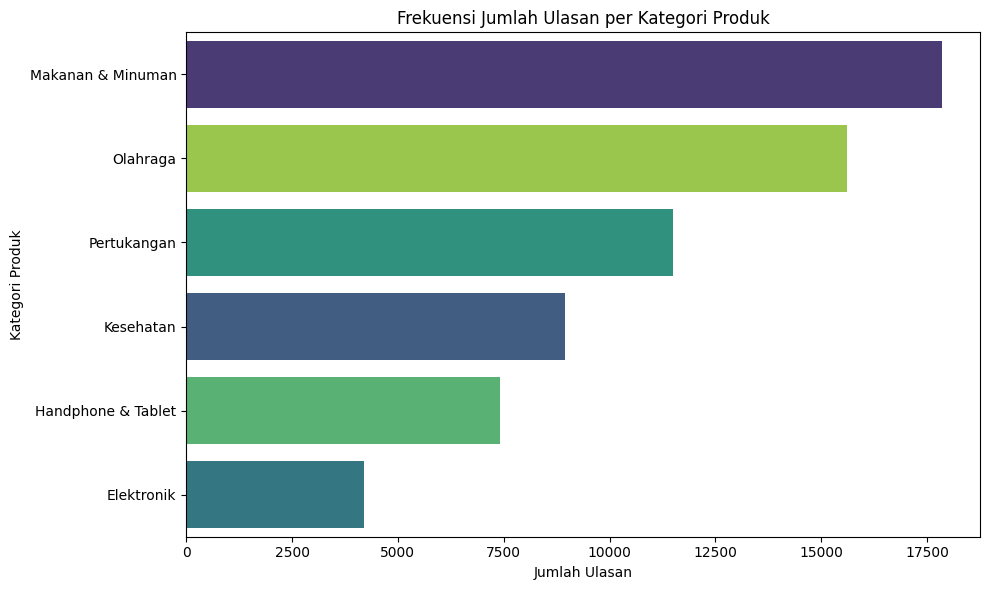

In [ ]:
def plot_product_categories():
    pass

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='product_category', order=df['product_category'].value_counts().index, hue='product_category', palette='viridis', legend=False)
plt.title('Frekuensi Jumlah Ulasan per Kategori Produk')
plt.xlabel('Jumlah Ulasan')
plt.ylabel('Kategori Produk')
plt.tight_layout()
plt.show()

**Interpretasi 2:** Berdasarkan hasil visualisasi dari frekuensi jumlah ulasan pada setiap kategori produk, kategori makanan dan minuman memiliki jumlah ulasan paling tinggi (sekitar lebih dari 17.500 ulasan), diikuti oleh kategori olahraga dengan jumlah ulasan tertinggi kedua, dan kategori pertukangan dengan jumlah ulasan tertinggi ketiga. Sementara itu, kategori elektronik memiliki jumlah ulasan yang jauh lebih sedikit dibandingkan kategori teratas (diantara 2.500-5.000 ulasan). Hal ini menunjukkan adanya ketimpangan yang cukup signifikan antar kategori, dimana hanya beberapa kategori yang mendominasi jumlah ulasan dari pelanggan.

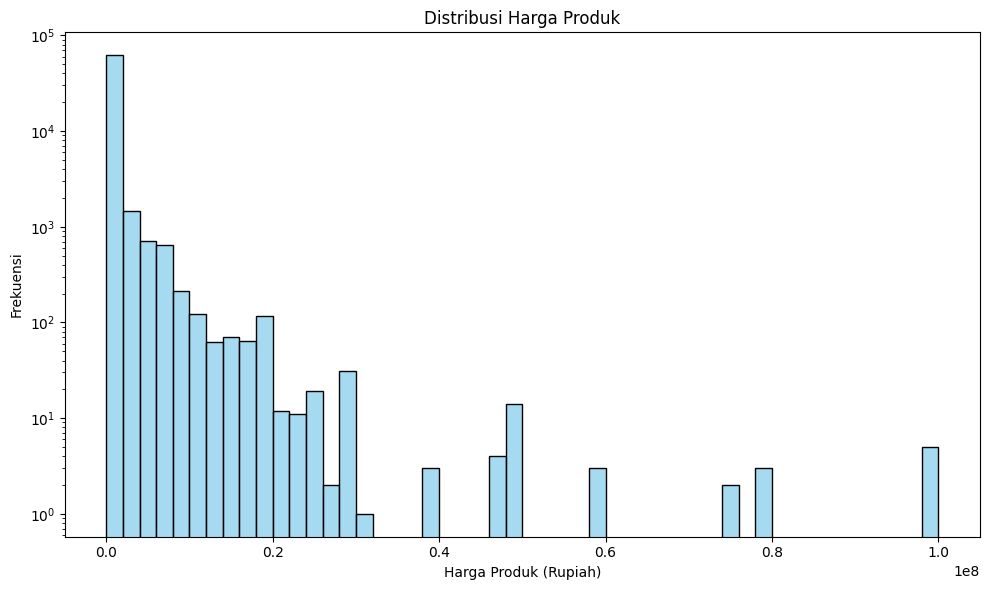

In [ ]:
def plot_price_distribution():
    pass

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='product_price', bins=50, color='skyblue')
plt.title('Distribusi Harga Produk')
plt.xlabel('Harga Produk (Rupiah)')
plt.ylabel('Frekuensi')
plt.yscale('log')
plt.tight_layout()
plt.show()

**Interpretasi 3:** Berdasarkan hasil visualisasi histogram, data distribusi harga produk tidak terdistribusi secara normal. Kurva menunjukkan bentuk yang cenderung miring ke kanan (right-skewed), yang terlihat dari batang histogram yang tinggi di sisi kiri (harga rendah) dan semakin mengecil ke arah kanan, meskipun terdapat sedikit fluktuasi pada beberapa rentang harga. Hal ini menunjukkan bahwa mayoritas produk terkonsentrasi pada rentang harga murah, ditunjukkan dengan produk berharga Rp0-Rp20.000 yang mendominasi pada dataset ini. Sementara itu, produk dengan harga tinggi jumlahnya jauh lebih sedikit, yang terlihat dari frekuensi yang lebih rendah pada bagian kanan grafik.

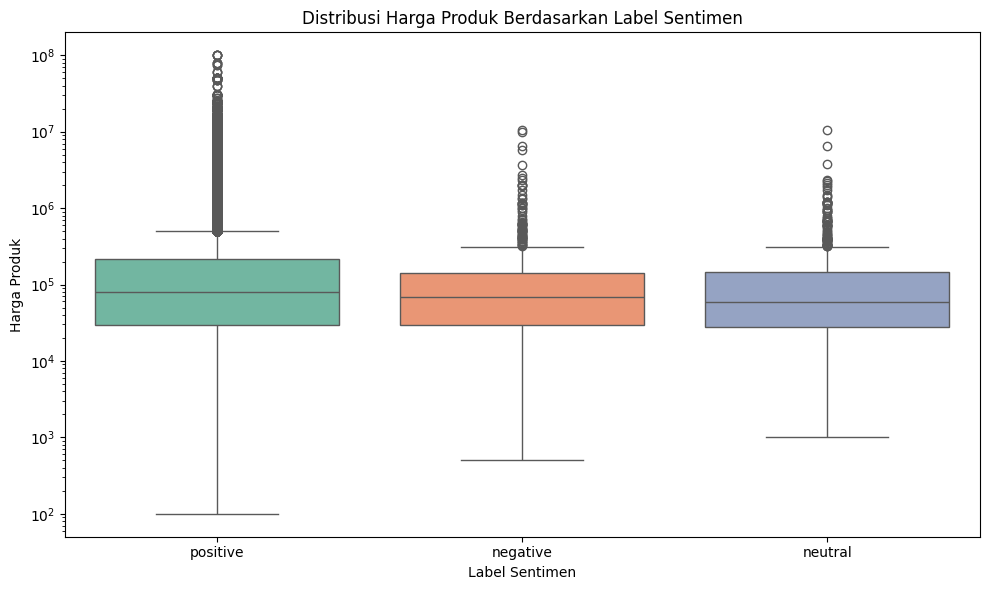

In [ ]:
def plot_price_by_sentiment():
    pass

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sentiment_label', y='product_price', hue='sentiment_label', palette='Set2', legend=False)
plt.title('Distribusi Harga Produk Berdasarkan Label Sentimen')
plt.xlabel('Label Sentimen')
plt.ylabel('Harga Produk')
plt.yscale('log')
plt.tight_layout()
plt.show()

**Interpretasi 4:** Berdasarkan hasil visualisasi boxplot dari distribusi harga produk pada masing-masing kategori sentimen, terlihat bahwa ketiga kelompok tersebut (positif, negatif, dan neutral) memiliki pola yang relatif mirip dengan median yang tidak berbeda jauh. Hal ini menunjukkan bahwa harga produk, baik mahal maupun murah, tidak secara langsung menentukan sentimen negatif. Sementara itu, terlihat outlier harga yang sangat tinggi pada setiap kategori sentimen, terutama pada sentimen positif, yang menunjukkan adanya produk dengan harga yang sangat ekstrem dalam dataset.  

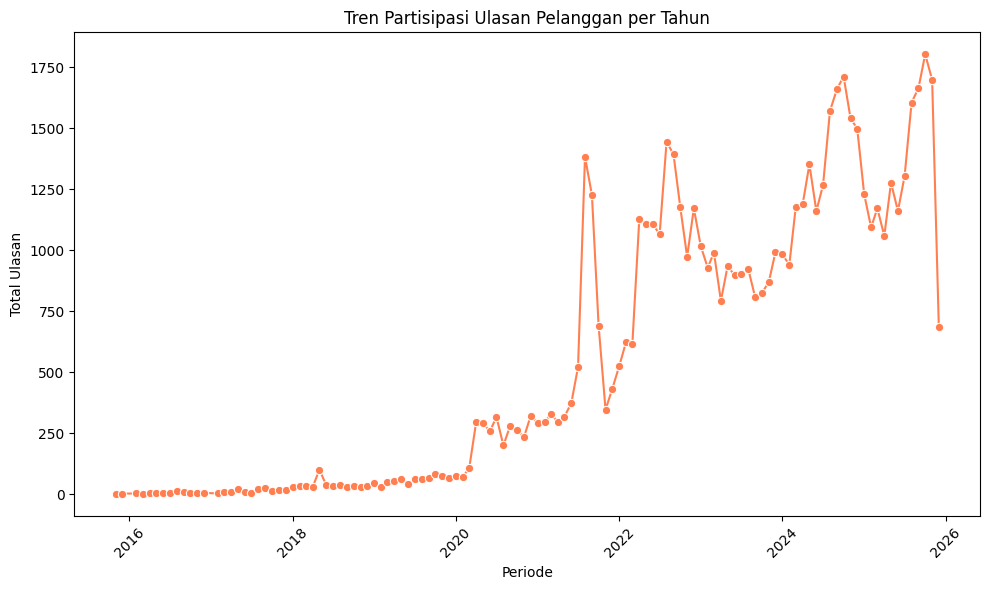

In [ ]:
def plot_review_trends():
    pass

df_trend = df.groupby(df['review_date'].dt.to_period('M')).size().reset_index(name='jumlah_ulasan')
df_trend['review_date'] = df_trend['review_date'].dt.to_timestamp()

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_trend, x='review_date', y='jumlah_ulasan', marker='o', color='coral')
plt.title('Tren Partisipasi Ulasan Pelanggan per Tahun')
plt.xlabel('Periode')
plt.ylabel('Total Ulasan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretasi 5:** Berdasarkan hasil visualisasi tren, terdapat peningkatan jumlah ulasan pelanggan dengan kenaikan yang cukup signifikan terutama setelah tahun 2020. Hal ini terlihat dengan adanya beberapa periode dengan lonjakan yang cukup tajam, khususnya sekitar tahun 2021 dan tahun 2025, dimana jumlah ulasan meningkat drastis dibandingkan periode sebelumnya. Lonjakan ini kemungkinan disebabkan oleh faktor seperti peningkatan aktivitas belanja online, promo besar-besaran tanggal kembar, atau perubahan perilaku konsumen setelah pandemi.

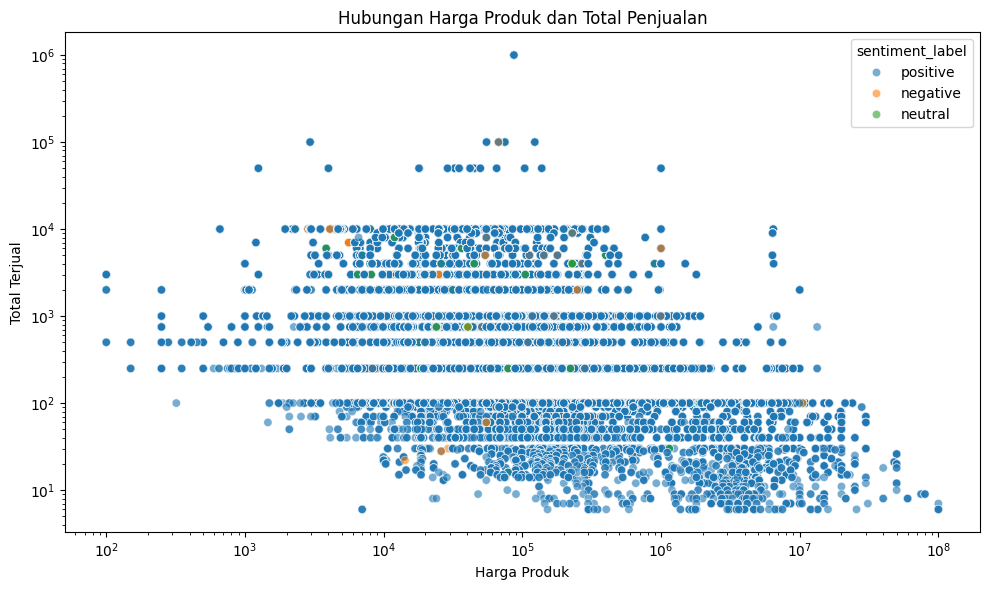

In [ ]:
def plot_price_vs_sales():
    pass

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='product_price', y='sold_count', hue='sentiment_label', alpha=0.6)
plt.title('Hubungan Harga Produk dan Total Penjualan')
plt.xlabel('Harga Produk')
plt.ylabel('Total Terjual')
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.show()

**Interpretasi 6:** Berdasarkan hasil visualisasi scatter plot, tidak terlihat adanya korelasi yang menunjukkan hubungan antara harga produk dan total penjualan. Produk dengan harga rendah cenderung memiliki jumlah penjualan yang lebih tinggi, namun terdapat juga beberapa produk dengan harga tinggi yang tetap memiliki penjualan yang cukup besar. Berdasarkan warna sentiment_label, terlihat bahwa produk yang laris tidak selalu memiliki sentimen positif, karena terdapat beberapa titik dengan sentimen negatif atau neutral pada penjualan yang tinggi.

**Kesimpulan Akhir:**

Berdasarkan hasil analisis, dapat disimpulkan bahwa kategori produk seperti makanan dan minuman serta olahraga mendominasi jumlah ulasan pelanggan, yang menunjukkan tingginya aktivitas dan minat pasar pada kategori tersebut. Selain itu, distribusi harga produk cenderung terpusat pada harga rendah, dan tidak ditemukan hubungan yang kuat antara harga dengan jumlah penjualan maupun sentimen pelanggan. Hal ini menunjukkan bahwa produk dengan harga murah maupun mahal tetap berpotensi memiliki performa penjualan yang baik serta mendapatkan berbagai jenis sentimen, sehingga harga bukan menjadi satu-satunya faktor penentu dalam membentuk kepuasan pelanggan dan performa penjualan.

Sebagai rekomendasi, seller di Tokopedia disarankan untuk meningkatkan kualitas produk dan pengalaman pelanggan untuk menjaga sentimen tetap positif. Seller juga dapat memanfaatkan kategori dengan jumlah ulasan tinggi sebagai peluang pasar utama, dengan cara meningkatkan stok, variasi produk, atau memberikan promo pada periode tertentu untuk meningkatkan penjualan. Selain itu, seller juga dapat menyesuaikan strategi harga pada rentang harga menengah ke bawah, karena segmen ini mendominasi pasar dan memiliki potensi penjualan yang lebih besar. Untuk produk dengan sentimen negatif, seller disarankan melakukan evaluasi terhadap kualitas produk agar lebih sesuai dengan ekspektasi pelanggan.